Portfolio Budget Performance: 93.6% are on budget.


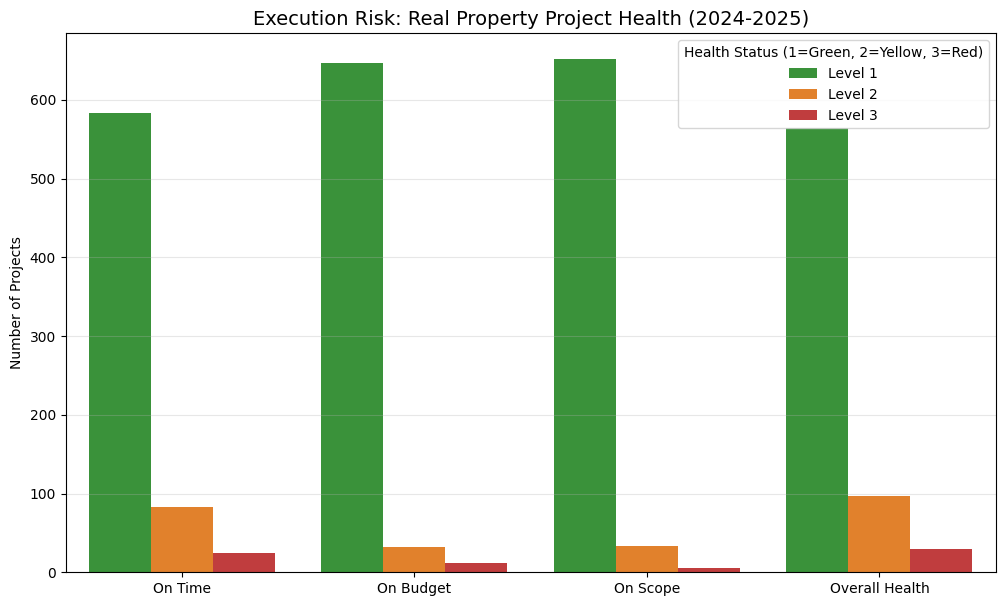

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
proj_df = pd.read_csv('projimmobiliersbudget-realpropertyprojbudget-2024-2025.csv', encoding='latin1')

# Map columns to friendly names
kpis = {
    'On-time_Respect-des-delais': 'On Time',
    'On-budget_Respect-du-budget': 'On Budget',
    'On-scope_Respect-de-la-portee': 'On Scope',
    'Overall-project-health_Sante-globale-du-projet': 'Overall Health'
}

# Transform for plotting
plot_data = []
for col, label in kpis.items():
    counts = proj_df[col].value_counts().sort_index()
    for status, count in counts.items():
        plot_data.append({'Metric': label, 'Status': f"Level {status}", 'Count': count})

df_plot = pd.DataFrame(plot_data)

# Visualize Project Health
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Count', hue='Status', data=df_plot, palette=['#2ca02c', '#ff7f0e', '#d62728'])
plt.title('Execution Risk: Real Property Project Health (2024-2025)', fontsize=14)
plt.ylabel('Number of Projects')
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Health Status (1=Green, 2=Yellow, 3=Red)')
plt.savefig('project_health_dashboard.png')

# Quick stat for your notes
on_budget_rate = (proj_df['On-budget_Respect-du-budget'] == 1).mean() * 100
print(f"Portfolio Budget Performance: {on_budget_rate:.1f}% are on budget.")